# Phần 2 – Bài toán Phân lớp
## EDA & Tiền xử lý Dữ liệu
**Dataset:** Adult Census Income  
**Target:** `income` (`<=50K` = 0, `>50K` = 1)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

---
## 1. Mô tả Dữ liệu

In [2]:
df = pd.read_csv('../../data/archive (11)/adult.csv')

# '?' là ký hiệu missing trong dataset này
df.replace('?', np.nan, inplace=True)
# Xóa khoảng trắng thừa trong string columns
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

print('='*55)
print(f'Shape : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print('='*55)
print(df.dtypes)
df.head()

Shape : 32,561 rows  x  15 columns
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
meta = {
    'age'           : 'Tuổi (numeric)',
    'workclass'     : 'Loại hình làm việc (categorical)',
    'fnlwgt'        : 'Final weight – trọng số thống kê Census (numeric)',
    'education'     : 'Trình độ học vấn dạng chuỗi (categorical) – sẽ drop',
    'education.num' : 'Trình độ học vấn dạng số, tương đương education (numeric)',
    'marital.status': 'Tình trạng hôn nhân (categorical)',
    'occupation'    : 'Nghề nghiệp (categorical)',
    'relationship'  : 'Quan hệ gia đình (categorical)',
    'race'          : 'Chủng tộc (categorical)',
    'sex'           : 'Giới tính (categorical)',
    'capital.gain'  : 'Thu nhập từ vốn (numeric)',
    'capital.loss'  : 'Mất vốn (numeric)',
    'hours.per.week': 'Số giờ làm mỗi tuần (numeric)',
    'native.country': 'Quốc gia gốc (categorical)',
    'income'        : 'Thu nhập >50K hay <=50K — TARGET (binary)',
}
pd.DataFrame.from_dict(meta, orient='index', columns=['Ý nghĩa'])

,Ý nghĩa
age,Tuổi (numeric)
workclass,Loại hình làm việc (categorical)
fnlwgt,Final weight – trọng số thống kê Census (numeric)
education,Trình độ học vấn dạng chuỗi (categorical) – sẽ...
education.num,"Trình độ học vấn dạng số, tương đương educatio..."
marital.status,Tình trạng hôn nhân (categorical)
occupation,Nghề nghiệp (categorical)
relationship,Quan hệ gia đình (categorical)
race,Chủng tộc (categorical)
sex,Giới tính (categorical)


---
## 2. Phân tích Khám phá (EDA)
### 2.1 Thống kê mô tả

In [4]:
num_cols     = df.select_dtypes(include=np.number).columns.tolist()
cat_cols     = df.select_dtypes(include='object').columns.tolist()
cat_cols_feat = [c for c in cat_cols if c != 'income']

print('Numeric features :', num_cols)
print('Categorical features:', cat_cols_feat)
print()
df[num_cols].describe().T.round(2)

Numeric features : ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Categorical features: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']



,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.58,13.64,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.37,105549.98,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.08,2.57,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.65,7385.29,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.30,402.96,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.44,12.35,1.0,40.0,40.0,45.0,99.0


In [5]:
for col in cat_cols_feat:
    print(f'── {col} ({df[col].nunique()} unique) ──')
    print(df[col].value_counts().to_string())
    print()

── workclass (8 unique) ──
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7

── education (16 unique) ──
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51

── marital.status (7 unique) ──
marital.status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23

── occupation (14 unique) ──
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-m

### 2.2 Phân bố Target – Class Imbalance

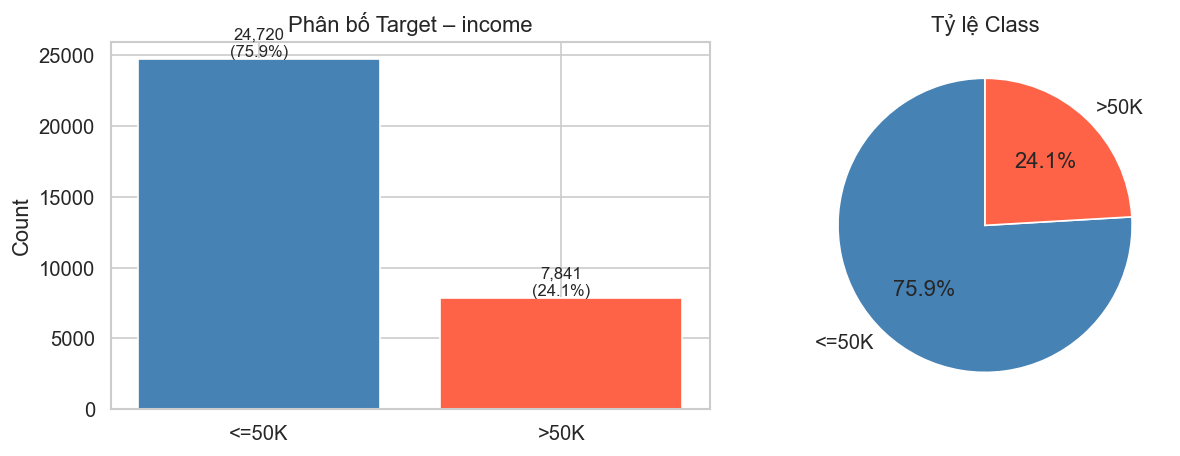

Imbalance ratio: 3.15:1
→ Mất cân bằng lớp – dùng F1/PR curve & class-weighted loss thay vì chỉ Accuracy.


In [6]:
target_counts = df['income'].value_counts()
target_pct    = df['income'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(target_counts.index, target_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
for i, (cnt, pct) in enumerate(zip(target_counts, target_pct)):
    axes[0].text(i, cnt + 200, f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Phân bố Target – income')
axes[0].set_ylabel('Count')

axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Tỷ lệ Class')

plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()

ratio = target_counts.max() / target_counts.min()
print(f'Imbalance ratio: {ratio:.2f}:1')
print('→ Mất cân bằng lớp – dùng F1/PR curve & class-weighted loss thay vì chỉ Accuracy.')

### 2.3 Phân bố Numeric Features theo Class

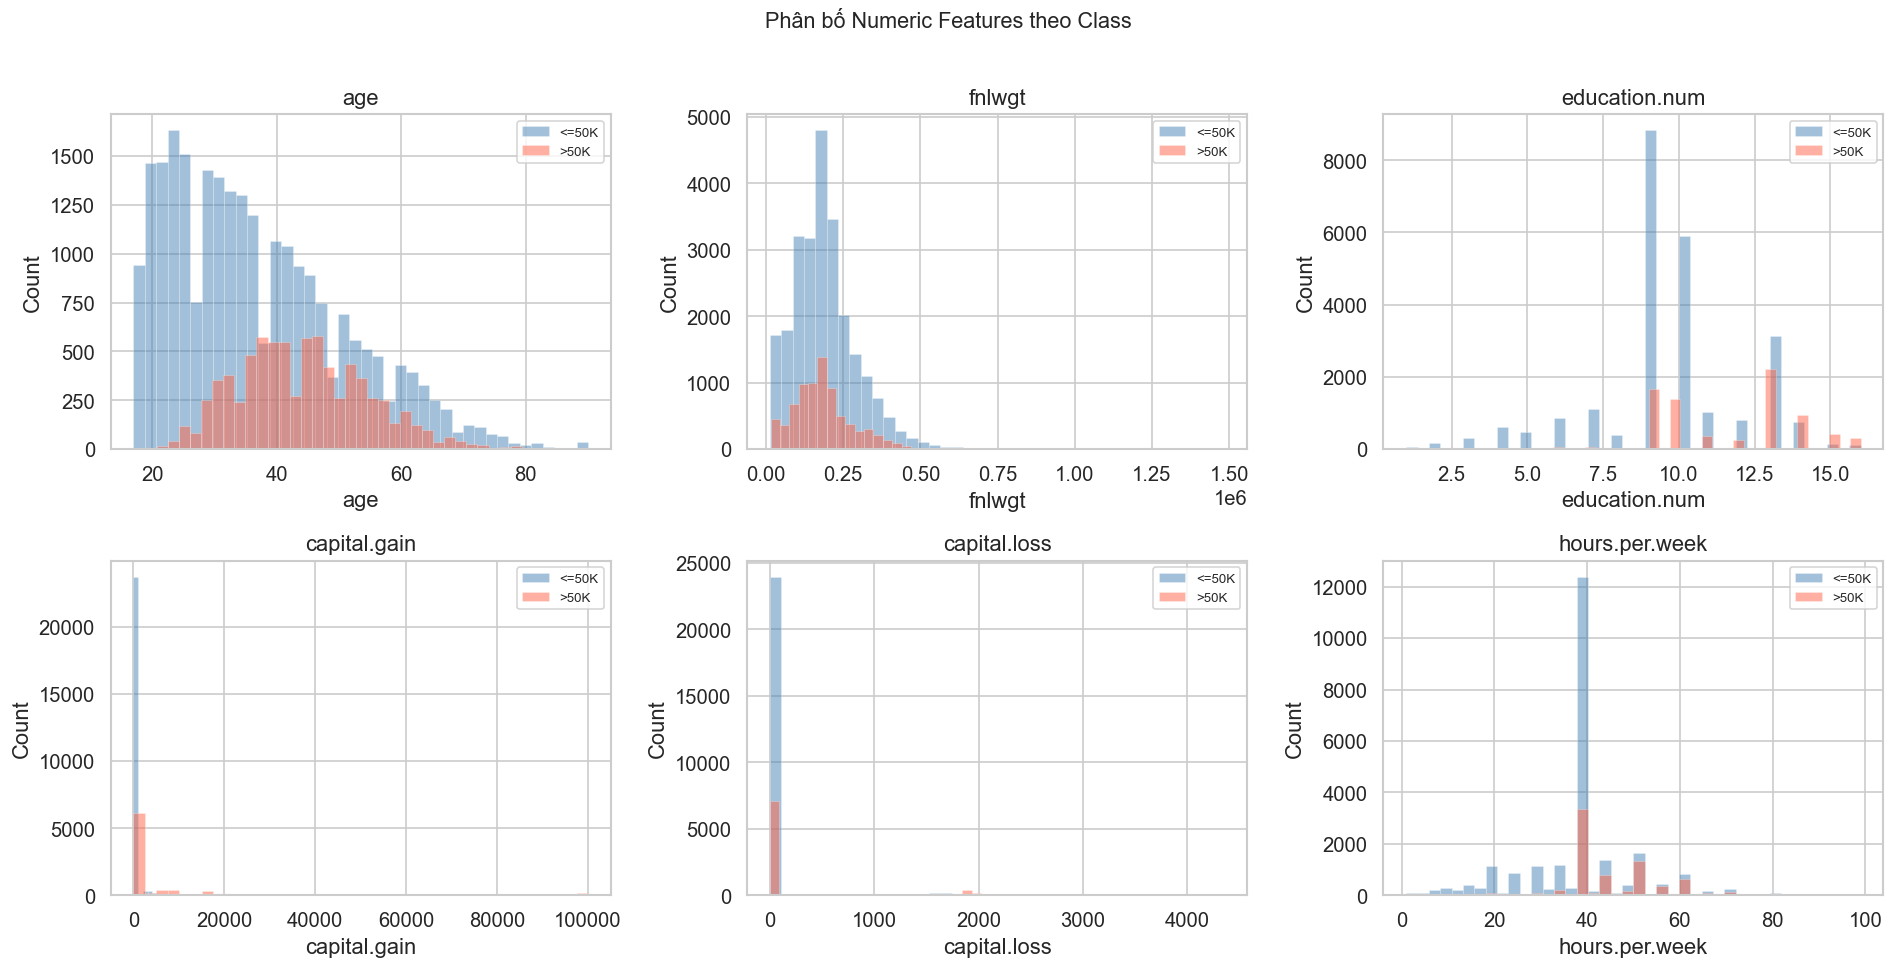

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in [('<=50K', 'steelblue'), ('>50K', 'tomato')]:
        subset = df[df['income'] == label][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.5, color=color,
                     label=label, edgecolor='white', linewidth=0.3)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phân bố Numeric Features theo Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('numeric_dist_by_class.png', bbox_inches='tight')
plt.show()

### 2.4 Categorical Features vs Target

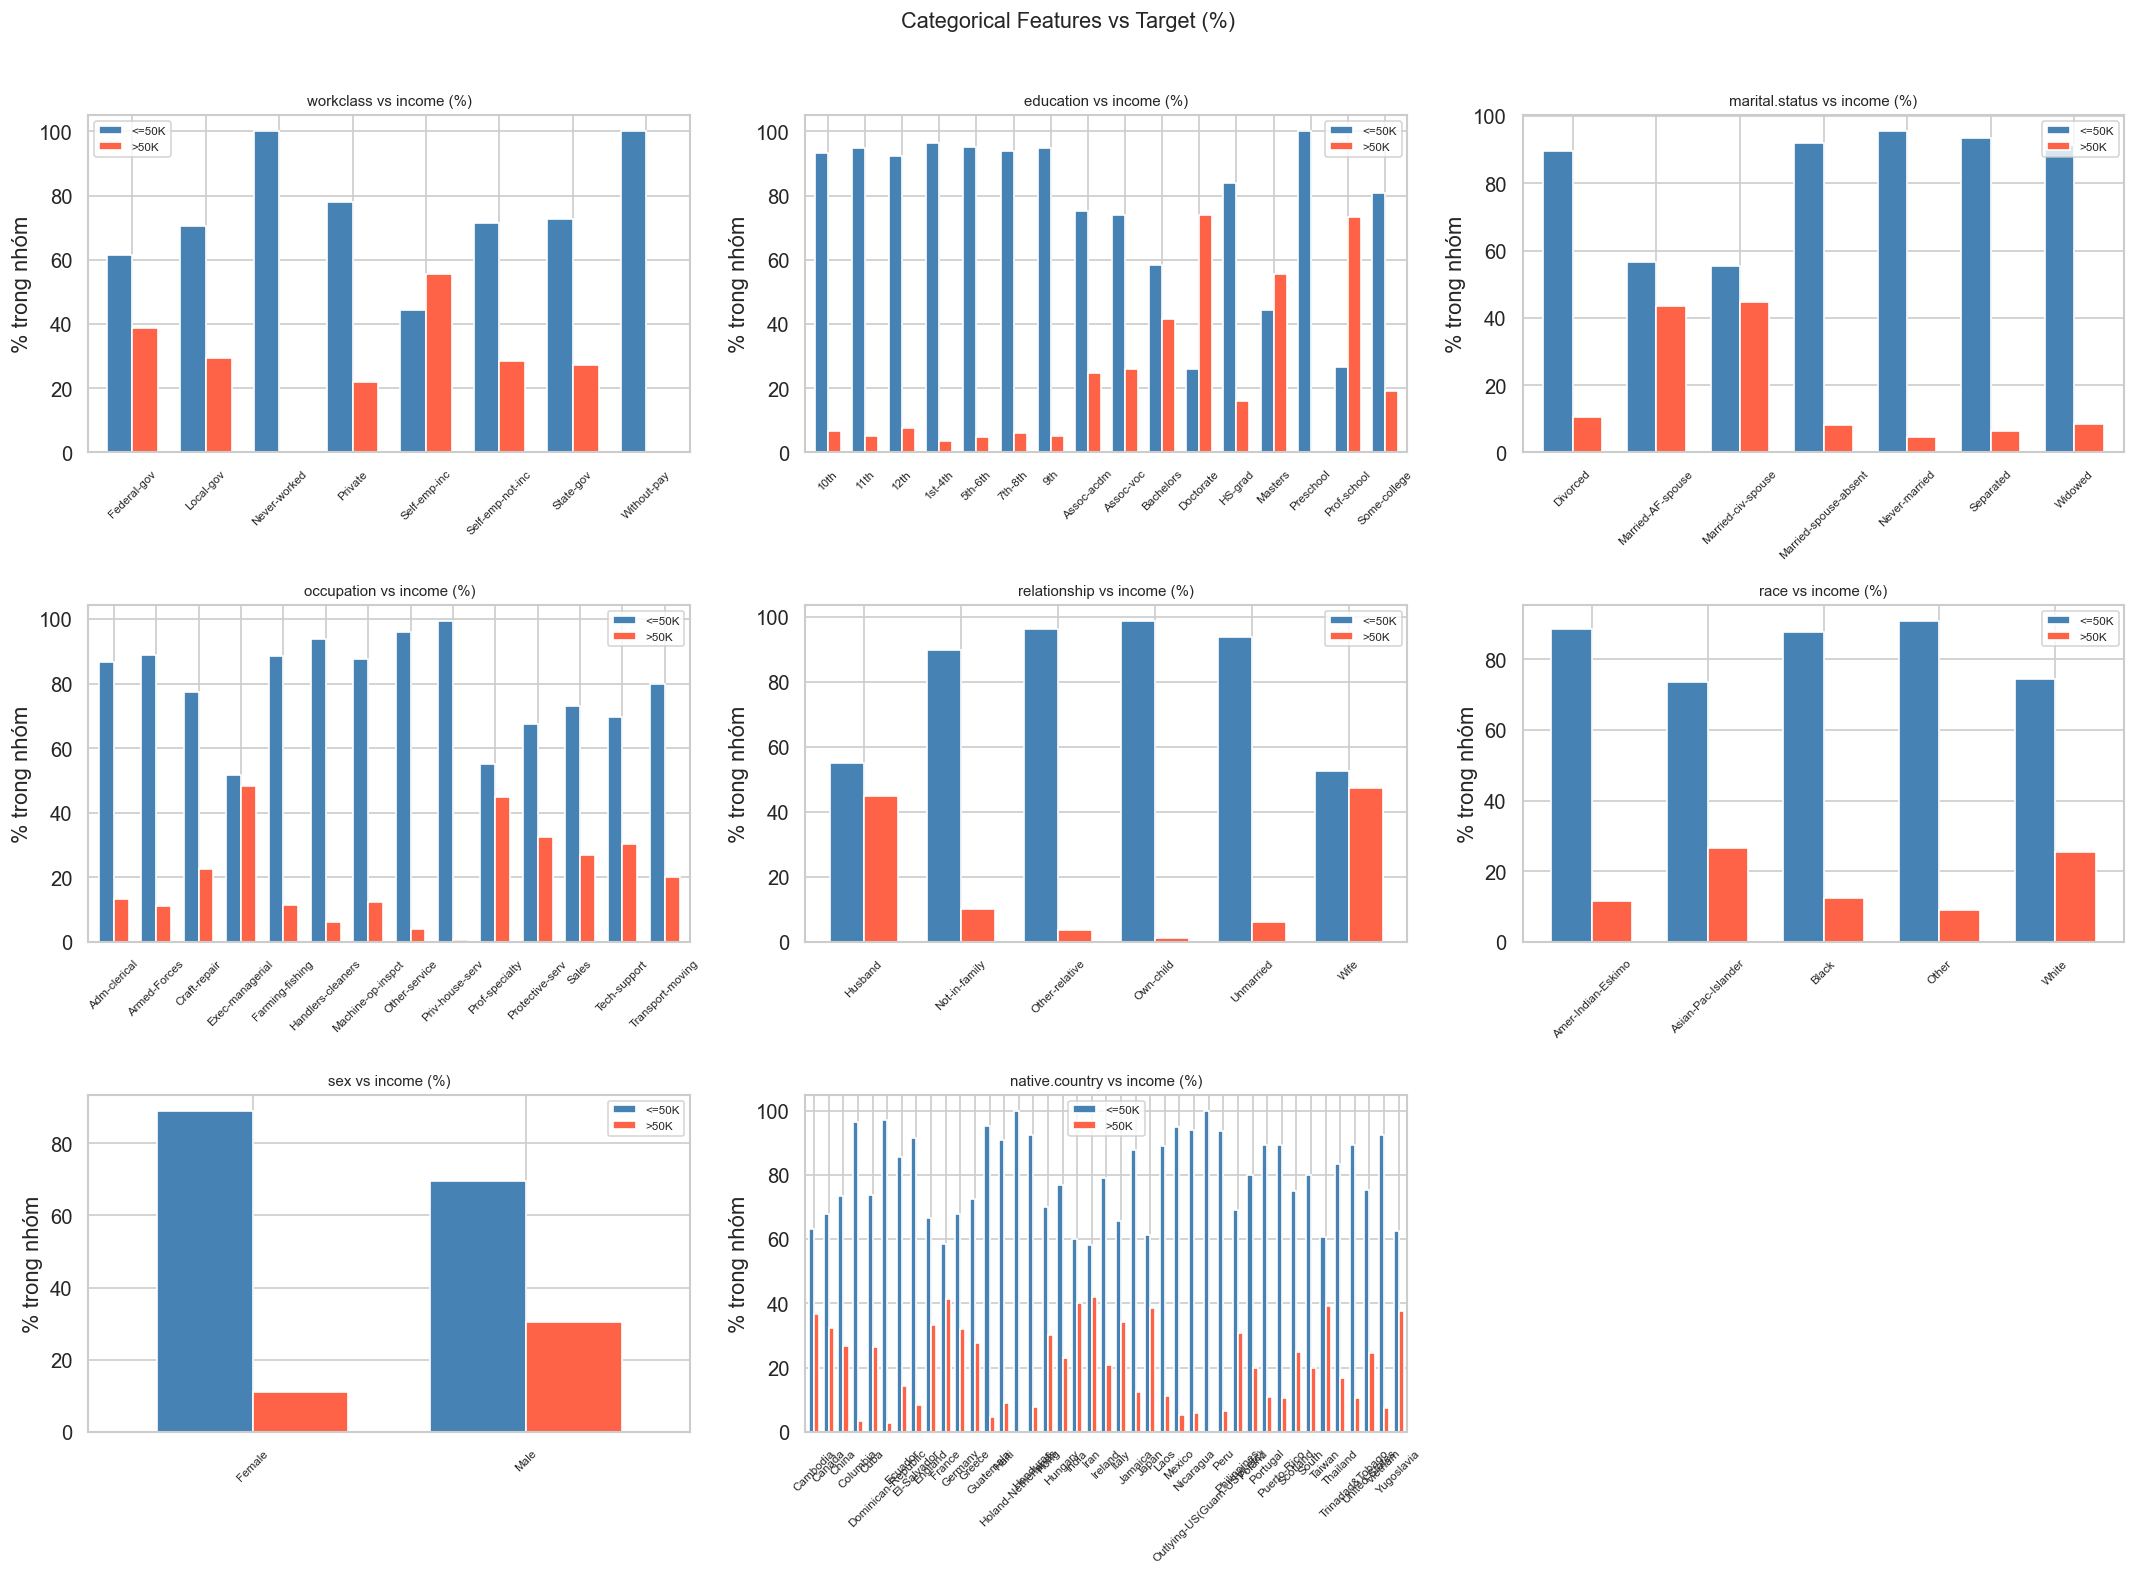

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()

for i, col in enumerate(cat_cols_feat):
    ct = pd.crosstab(df[col], df['income'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'],
            edgecolor='white', width=0.7)
    axes[i].set_title(f'{col} vs income (%)', fontsize=9)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% trong nhóm')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].legend(fontsize=7)

for j in range(len(cat_cols_feat), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs Target (%)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('categorical_vs_target.png', bbox_inches='tight')
plt.show()

### 2.5 Correlation Matrix

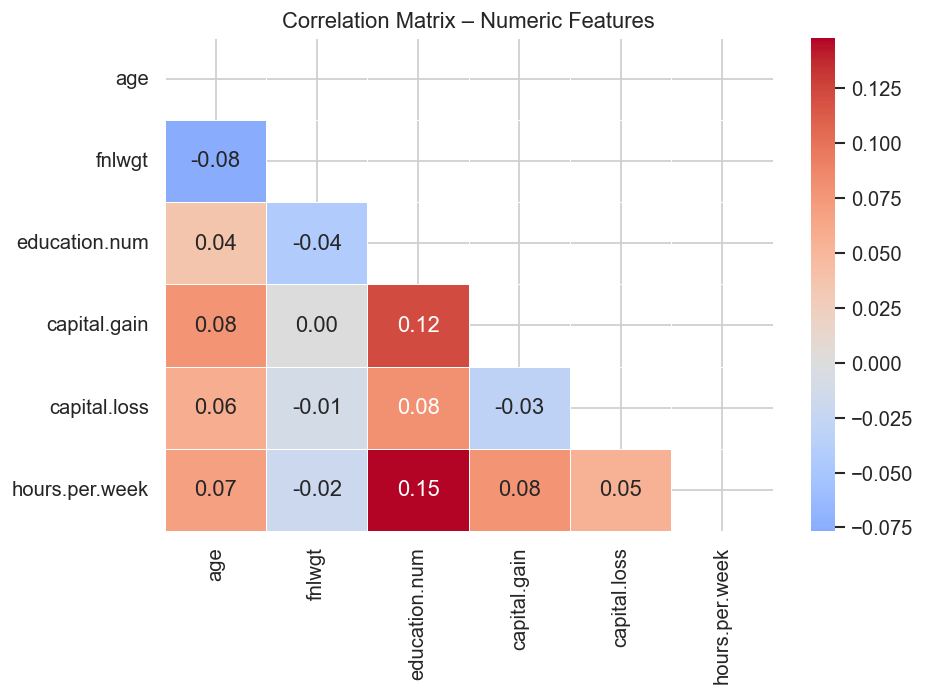

Lưu ý: education và education.num tương quan cao → drop education (string) khi encode.


In [9]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4, ax=ax)
ax.set_title('Correlation Matrix – Numeric Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

print('Lưu ý: education và education.num tương quan cao → drop education (string) khi encode.')

### 2.6 Outlier Detection (IQR + Z-score)

In [10]:
def detect_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR))

def detect_outliers_zscore(series, threshold=3.0):
    z = np.abs(stats.zscore(series.dropna()))
    mask = pd.Series(False, index=series.index)
    mask[series.dropna().index] = z > threshold
    return mask

print(f"{'Feature':<20} {'IQR':>10} {'Z-score':>10} {'% IQR':>8}")
print('-' * 52)
for col in num_cols:
    n_iqr = detect_outliers_iqr(df[col]).sum()
    n_z   = detect_outliers_zscore(df[col]).sum()
    pct   = 100 * n_iqr / len(df)
    print(f"{col:<20} {n_iqr:>10,} {n_z:>10,} {pct:>7.2f}%")

Feature                     IQR    Z-score    % IQR
----------------------------------------------------
age                         143        121    0.44%
fnlwgt                      992        347    3.05%
education.num             1,198        219    3.68%
capital.gain              2,712        215    8.33%
capital.loss              1,519      1,470    4.67%
hours.per.week            9,008        440   27.66%


---
## 3. Tiền xử lý
### 3.1 Xử lý Missing Values

In [23]:
df = pd.read_csv('../../data/archive (11)/adult.csv')

# '?' là ký hiệu missing trong dataset này → chuyển thành NaN
df.replace('?', np.nan, inplace=True)
# Xóa khoảng trắng thừa trong string columns
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

print('='*55)
print(f'Shape : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print('='*55)

# Kiểm tra missing NGAY SAU KHI replace
print('\nMissing values trước xử lý:')
missing = df.isnull().sum()
print(missing[missing > 0])

# Xử lý missing tổng quát
for col in df.columns:
    n_missing = df[col].isnull().sum()
    if n_missing == 0:
        continue
    if df[col].dtype == 'object':
        fill_val = df[col].mode()[0]
        strategy = 'mode'
    else:
        fill_val = df[col].median()
        strategy = 'median'
    df[col].fillna(fill_val, inplace=True)
    print(f'  [{strategy}] {col}: điền {n_missing} missing → "{fill_val}"')

print(f'\nMissing còn lại: {df.isnull().sum().sum()}')

Shape : 32,561 rows  x  15 columns

Missing values trước xử lý:
workclass         1836
occupation        1843
native.country     583
dtype: int64
  [mode] workclass: điền 1836 missing → "Private"
  [mode] occupation: điền 1843 missing → "Prof-specialty"
  [mode] native.country: điền 583 missing → "United-States"

Missing còn lại: 0


### 3.2 Encode Target + Drop Redundant Columns

In [12]:
# <=50K → 0,  >50K → 1
df['income'] = (df['income'] == '>50K').astype(int)
print('Target:', df['income'].value_counts().to_dict())

# Drop 'education' vì education.num đã encode thông tin tương đương
df.drop(columns=['education'], inplace=True)
print('Drop cột "education" → shape:', df.shape)

Target: {0: 24720, 1: 7841}
Drop cột "education" → shape: (32561, 14)


### 3.3 One-Hot Encoding

In [13]:
cat_to_encode = df.select_dtypes(include='object').columns.tolist()
print('Encode:', cat_to_encode)
print('Unique values:')
for c in cat_to_encode:
    print(f'  {c}: {df[c].nunique()}')

# drop_first=True tránh dummy variable trap (multicollinearity)
df_enc = pd.get_dummies(df, columns=cat_to_encode, drop_first=True)

print(f'\nShape trước encode : {df.shape}')
print(f'Shape sau encode   : {df_enc.shape}')
print(f'Cột tăng thêm      : {df_enc.shape[1] - df.shape[1]}')

Encode: ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Unique values:
  workclass: 8
  marital.status: 7
  occupation: 14
  relationship: 6
  race: 5
  sex: 2
  native.country: 41

Shape trước encode : (32561, 14)
Shape sau encode   : (32561, 83)
Cột tăng thêm      : 69


### 3.4 Stratified Train / Val / Test Split

In [14]:
from sklearn.model_selection import train_test_split

X = df_enc.drop(columns=['income'])
y = df_enc['income'].values
feature_names = X.columns.tolist()

# Stratified để giữ tỷ lệ class trong mỗi tập
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.125, random_state=SEED, stratify=y_trainval)

print(f'Train : {X_train.shape[0]:,}  ({100*X_train.shape[0]/len(df):.1f}%)')
print(f'Val   : {X_val.shape[0]:,}    ({100*X_val.shape[0]/len(df):.1f}%)')
print(f'Test  : {X_test.shape[0]:,}   ({100*X_test.shape[0]/len(df):.1f}%)')
print()
for name, arr in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    pos = arr.mean() * 100
    print(f'  {name}: {100-pos:.1f}% neg  |  {pos:.1f}% pos  (stratified ✓)')

Train : 22,792  (70.0%)
Val   : 3,256    (10.0%)
Test  : 6,513   (20.0%)

  Train: 75.9% neg  |  24.1% pos  (stratified ✓)
  Val: 75.9% neg  |  24.1% pos  (stratified ✓)
  Test: 75.9% neg  |  24.1% pos  (stratified ✓)


### 3.5 StandardScaler (numeric cols only)

In [15]:
from sklearn.preprocessing import StandardScaler

# Chỉ scale numeric, binary 0/1 giữ nguyên
binary_cols  = [c for c in feature_names if df_enc[c].nunique() == 2]
numeric_cols = [c for c in feature_names if c not in binary_cols]
num_idx      = [feature_names.index(c) for c in numeric_cols]

print(f'Numeric scale  : {len(numeric_cols)} cols')
print(f'Binary giữ nguyên: {len(binary_cols)} cols')

scaler = StandardScaler()

X_train_s = X_train.values.astype(float).copy()
X_val_s   = X_val.values.astype(float).copy()
X_test_s  = X_test.values.astype(float).copy()

# fit ONLY trên train → tránh data leakage
X_train_s[:, num_idx] = scaler.fit_transform(X_train_s[:, num_idx])
X_val_s  [:, num_idx] = scaler.transform(X_val_s  [:, num_idx])
X_test_s [:, num_idx] = scaler.transform(X_test_s [:, num_idx])

print('Scale xong!')

Numeric scale  : 6 cols
Binary giữ nguyên: 76 cols
Scale xong!


### 3.6 Lưu Processed Data

In [16]:
import joblib, os

os.makedirs('../../data/processed_clf', exist_ok=True)

np.save('../../data/processed_clf/X_train.npy', X_train_s)
np.save('../../data/processed_clf/X_val.npy',   X_val_s)
np.save('../../data/processed_clf/X_test.npy',  X_test_s)
np.save('../../data/processed_clf/y_train.npy', y_train)
np.save('../../data/processed_clf/y_val.npy',   y_val)
np.save('../../data/processed_clf/y_test.npy',  y_test)
joblib.dump(scaler,        '../../data/processed_clf/scaler.pkl')
joblib.dump(feature_names, '../../data/processed_clf/feature_names.pkl')
joblib.dump(numeric_cols,  '../../data/processed_clf/numeric_cols.pkl')
joblib.dump(binary_cols,   '../../data/processed_clf/binary_cols.pkl')

print('Lưu xong! Files:', os.listdir('../../data/processed_clf'))

Lưu xong! Files: ['binary_cols.pkl', 'feature_names.pkl', 'numeric_cols.pkl', 'scaler.pkl', 'X_test.npy', 'X_train.npy', 'X_val.npy', 'y_test.npy', 'y_train.npy', 'y_val.npy']


---
## 4. Tóm tắt

In [17]:
summary = {
    'Tổng số mẫu'              : f'{len(df):,}',
    'Số features sau encode'   : X.shape[1],
    'Missing còn lại'          : df_enc.isnull().sum().sum(),
    'Train / Val / Test'       : f'{X_train.shape[0]:,} / {X_val.shape[0]:,} / {X_test.shape[0]:,}',
    'Class ratio (train)'      : f'{(1-y_train.mean())*100:.1f}% neg / {y_train.mean()*100:.1f}% pos',
    'Stratified split'         : 'Yes',
    'Scaler'                   : 'StandardScaler (numeric only)',
}
for k, v in summary.items():
    print(f'  {k:<30}: {v}')

print()
print('Lưu ý cho báo cáo:')
print('  • Imbalance ~75/25 → dùng F1, PR curve, class-weighted loss')
print('  • Stratified k-fold (k=5) khi chọn lambda')
print('  • fnlwgt là trọng số Census, có thể thử drop để so sánh')

  Tổng số mẫu                   : 32,561
  Số features sau encode        : 82
  Missing còn lại               : 0
  Train / Val / Test            : 22,792 / 3,256 / 6,513
  Class ratio (train)           : 75.9% neg / 24.1% pos
  Stratified split              : Yes
  Scaler                        : StandardScaler (numeric only)

Lưu ý cho báo cáo:
  • Imbalance ~75/25 → dùng F1, PR curve, class-weighted loss
  • Stratified k-fold (k=5) khi chọn lambda
  • fnlwgt là trọng số Census, có thể thử drop để so sánh
